In [2]:
# === Table 5a (Simulator vs IBM hardware) — Notebook-only, no files written ===
# Set your OUTDIR path:
OUTDIR = r"D:\PHYSIQUE MATHEMATIQUE\doctora\4 EME ANNE\articles\breast canser\implementations\qsvm_on_wcds\real QPU\SOURUN"

# Simulator baselines (higher replicate per policy)
ACC_SIM = 0.9386
F1_SIM  = 0.9524
AUC_SIM = 0.9825

BACKEND_NAME = "ibm_brisbane"

# ---------------- helpers ----------------
import json, statistics
from pathlib import Path
from datetime import datetime
import pandas as pd
from IPython.display import display, Markdown

def read_json(p: Path):
    with p.open("r", encoding="utf-8") as f:
        return json.load(f)

def percent(x: float) -> float:
    return 100.0 * float(x)

def mean(v):    return float(sum(v)/len(v)) if v else float("nan")
def median(v):  return float(statistics.median(v)) if v else float("nan")

def fmt_date_from_mtime(paths):
    mtimes = [Path(p).stat().st_mtime for p in paths if Path(p).exists()]
    if not mtimes: return "YYYY-MM-DD"
    return datetime.fromtimestamp(max(mtimes)).strftime("%Y-%m-%d")

def shots_string(adaptive: dict) -> str:
    base   = adaptive.get("base_shots", 256)
    band   = adaptive.get("band", [0.40, 0.60])
    sigma  = adaptive.get("sigma_target", 0.0125)
    cap    = adaptive.get("max_shots", 1025)
    return f"adaptive (base {base}; band {band[0]:.2f}\u2013{band[1]:.2f}; \u03c3={sigma:.4f}; cap={cap})"

# ---------------- load & validate ----------------
outdir = Path(OUTDIR)
req = [
    outdir / "fold1_summary.json",
    outdir / "fold2_summary.json",
    outdir / "fold3_summary.json",
    outdir / "run_summary.json",
]
missing = [str(p) for p in req if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n  " + "\n  ".join(missing))

folds = [read_json(outdir / f"fold{i}_summary.json") for i in (1,2,3)]
run_summary = read_json(outdir / "run_summary.json")

# ---------------- aggregate per rules ----------------
accs  = [float(f["Acc"]) for f in folds]
aucs  = [float(f["AUC"]) for f in folds]
f1s   = [float(f["F1"])  for f in folds]
sens  = [float(f["Sens"]) for f in folds]
spec  = [float(f["Spec"]) for f in folds]
prec  = [float(f["Prec"]) for f in folds]
rec   = [float(f["Rec"])  for f in folds]
thr   = [float(f["thr"]) for f in folds]
cstar = [float(f["C_best"]) for f in folds]
kern  = [float(f.get("kernel_seconds", 0.0)) for f in folds]
TP = sum(int(f["TP"]) for f in folds)
FP = sum(int(f["FP"]) for f in folds)
TN = sum(int(f["TN"]) for f in folds)
FN = sum(int(f["FN"]) for f in folds)

acc_hw = mean(accs); auc_hw = mean(aucs); f1_hw = mean(f1s)
sens_m = mean(sens); spec_m = mean(spec); prec_m = mean(prec); rec_m = mean(rec)
thr_m  = mean(thr);  cstar_med = median(cstar); kern_med = median(kern)

d_acc_pp = percent(acc_hw - ACC_SIM)
d_auc_pp = percent(auc_hw - AUC_SIM)

shots = shots_string(run_summary.get("Adaptive", {}))
date_str = fmt_date_from_mtime([outdir / "fold1_summary.json", outdir / "run_summary.json"])

# ---------------- build Table 5a (percent version) ----------------
cols = [
    "Backend","Date","Shots","Acc% (Sim)","Acc% (HW)","ΔAcc (pp)",
    "AUC (Sim)","AUC (HW)","ΔAUC (pp)","F1 (HW)",
    "TP/FP/TN/FN","Sens%/Spec%","Prec%/Rec%","C*","thr*","kernel_time_s (median)"
]
row = [
    BACKEND_NAME, date_str, shots,
    f"{percent(ACC_SIM):.1f}", f"{percent(acc_hw):.1f}", f"{d_acc_pp:+.1f}",
    f"{percent(AUC_SIM):.1f}", f"{percent(auc_hw):.1f}", f"{d_auc_pp:+.1f}",
    f"{f1_hw:.4f}",
    f"{TP}/{FP}/{TN}/{FN}",
    f"{percent(sens_m):.1f}/{percent(spec_m):.1f}",
    f"{percent(prec_m):.1f}/{percent(rec_m):.1f}",
    f"{cstar_med:g}", f"{thr_m:.6f}", f"{kern_med:.2f}",
]
table5a = pd.DataFrame([row], columns=cols)

# ---------------- decimals cross-check (no % conversions) ----------
check_cols = [
    "Acc(Sim)","Acc(HW_mean)","AUC(Sim)","AUC(HW_mean)","F1(HW_mean)",
    "Sens_mean","Spec_mean","Prec_mean","Rec_mean","C*_median","thr_mean","kernel_seconds_median"
]
check_row = [ACC_SIM, acc_hw, AUC_SIM, auc_hw, f1_hw, sens_m, spec_m, prec_m, rec_m, cstar_med, thr_m, kern_med]
decimals_check = pd.DataFrame([check_row], columns=check_cols)

# ---------------- display (Markdown, no .style/.jinja2 required) -------------
display(Markdown("### Table 5a — Simulator vs IBM hardware (percent form)"))
print(table5a.to_markdown(index=False))

display(Markdown("#### Decimals cross-check (validation)"))
print(decimals_check.to_markdown(index=False))


### Table 5a — Simulator vs IBM hardware (percent form)

| Backend      | Date       | Shots                                                   |   Acc% (Sim) |   Acc% (HW) |   ΔAcc (pp) |   AUC (Sim) |   AUC (HW) |   ΔAUC (pp) |   F1 (HW) | TP/FP/TN/FN   | Sens%/Spec%   | Prec%/Rec%   |   C* |     thr* |   kernel_time_s (median) |
|:-------------|:-----------|:--------------------------------------------------------|-------------:|------------:|------------:|------------:|-----------:|------------:|----------:|:--------------|:--------------|:-------------|-----:|---------:|-------------------------:|
| ibm_brisbane | 2025-10-25 | adaptive (base 256; band 0.40–0.60; σ=0.0125; cap=1025) |         93.9 |        84.4 |        -9.5 |        98.2 |       96.1 |        -2.1 |    0.8883 | 59/14/22/1    | 98.3/61.1     | 81.3/98.3    |    1 | 0.445419 |                   944.91 |


#### Decimals cross-check (validation)

|   Acc(Sim) |   Acc(HW_mean) |   AUC(Sim) |   AUC(HW_mean) |   F1(HW_mean) |   Sens_mean |   Spec_mean |   Prec_mean |   Rec_mean |   C*_median |   thr_mean |   kernel_seconds_median |
|-----------:|---------------:|-----------:|---------------:|--------------:|------------:|------------:|------------:|-----------:|------------:|-----------:|------------------------:|
|     0.9386 |        0.84375 |     0.9825 |       0.961111 |      0.888306 |    0.983333 |    0.611111 |     0.81257 |   0.983333 |           1 |   0.445419 |                 944.908 |


In [3]:
# Save Table 5a to CSV (percent form)
save_path = r"D:\PHYSIQUE MATHEMATIQUE\doctora\4 EME ANNE\articles\breast canser\implementations\qsvm_on_wcds\section_451_outputs\tables\Table5a_sim_vs_hw.csv"

import os
os.makedirs(os.path.dirname(save_path), exist_ok=True)
table5a.to_csv(save_path, index=False, encoding="utf-8")
print("Saved:", save_path)


Saved: D:\PHYSIQUE MATHEMATIQUE\doctora\4 EME ANNE\articles\breast canser\implementations\qsvm_on_wcds\section_451_outputs\tables\Table5a_sim_vs_hw.csv


In [ ]:
save_check = r"D:\PHYSIQUE MATHEMATIQUE\doctora\4 EME ANNE\articles\breast canser\implementations\qsvm_on_wcds\section_451_outputs\tables\Table5a_decimals_check.csv"
os.makedirs(os.path.dirname(save_check), exist_ok=True)
decimals_check.to_csv(save_check, index=False, encoding="utf-8")
print("Saved:", save_check)


Saved: D:\PHYSIQUE MATHEMATIQUE\doctora\4 EME ANNE\articles\breast canser\implementations\qsvm_on_wcds\section_451_outputs\tables\Table5a_decimals_check.csv


: 

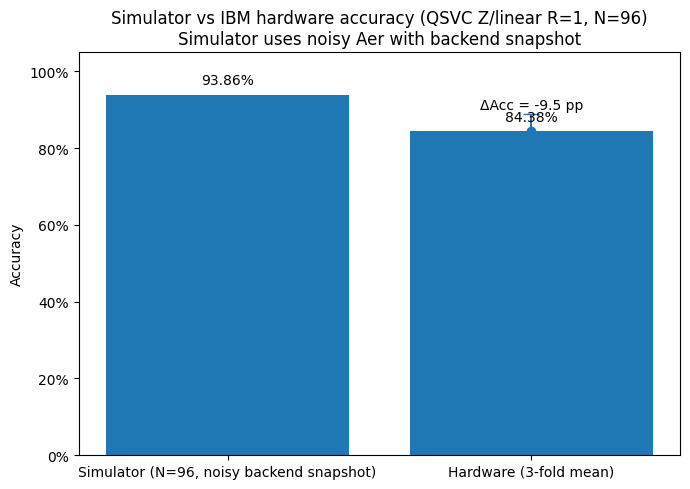

In [1]:
# Fig 11b — exact values shown, % axis up to 100%, noisy-snapshot note
OUTDIR = r"D:\PHYSIQUE MATHEMATIQUE\doctora\4 EME ANNE\articles\breast canser\implementations\qsvm_on_wcds\real QPU\SOURUN"
ACC_SIM = 0.9386  # simulator baseline (higher replicate)

import json, statistics
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

def _read(p):
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

folds = [_read(Path(OUTDIR)/f"fold{i}_summary.json") for i in (1,2,3)]
accs  = [float(f["Acc"]) for f in folds]
hw_mean = float(sum(accs)/len(accs))
hw_std  = float(statistics.pstdev(accs)) if len(accs) > 1 else 0.0
delta_pp = 100.0 * (hw_mean - ACC_SIM)

labels = ["Simulator (N=96, noisy backend snapshot)", "Hardware (3-fold mean)"]
vals = [ACC_SIM, hw_mean]

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
bars = ax.bar(x, vals)

# error bar on HW
if hw_std > 0:
    ax.errorbar(x[1], vals[1], yerr=hw_std, fmt="o", capsize=6)

# y-axis as percent, include 100%
ax.set_ylim(0, 1.05)  # headroom for labels while keeping 100% visible
ax.set_yticks(np.linspace(0, 1.0, 6))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Accuracy")
ax.set_title("Simulator vs IBM hardware accuracy (QSVC Z/linear R=1, N=96)\nSimulator uses noisy Aer with backend snapshot")

# exact value labels on each bar (as %)
for xi, v in zip(x, vals):
    ax.text(xi, v + 0.02, f"{v*100:.2f}%", ha="center", va="bottom", fontsize=10)

# ΔAcc annotation above the HW bar
ax.annotate(f"ΔAcc = {delta_pp:+.1f} pp",
            xy=(x[1], vals[1]), xytext=(0, 14),
            textcoords="offset points", ha="center", va="bottom")

fig.tight_layout()
plt.show()

# Optional saves:
# fig.savefig(r"D:\path\to\Fig11b_sim_vs_hw_accuracy.png", dpi=300)
# fig.savefig(r"D:\path\to\Fig11b_sim_vs_hw_accuracy.svg")
# fig.savefig(r"D:\path\to\Fig11b_sim_vs_hw_accuracy.pdf")


In [3]:
# Compute pooled accuracy vs mean-of-fold accuracy
OUTDIR = r"D:\PHYSIQUE MATHEMATIQUE\doctora\4 EME ANNE\articles\breast canser\implementations\qsvm_on_wcds\real QPU\SOURUN"

import json, statistics
from pathlib import Path

def _read(p):
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

folds = [_read(Path(OUTDIR)/f"fold{i}_summary.json") for i in (1,2,3)]

# Macro (mean of per-fold accuracies)
accs = [float(f["Acc"]) for f in folds]
acc_mean = sum(accs)/len(accs)
acc_std  = statistics.pstdev(accs) if len(accs) > 1 else 0.0

# Micro (pooled across all test samples)
TP = sum(int(f["TP"]) for f in folds)
FP = sum(int(f["FP"]) for f in folds)
TN = sum(int(f["TN"]) for f in folds)
FN = sum(int(f["FN"]) for f in folds)
pooled_acc = (TP + TN) / max(1, TP + TN + FP + FN)

print("Per-fold Acc:", [f"{a:.4f}" for a in accs])
print(f"Mean Acc across folds (macro): {acc_mean:.4f}  (std: {acc_std:.4f})")
print(f"Pooled Acc across folds (micro): {pooled_acc:.4f}")
print(f"Difference (micro - macro): {pooled_acc - acc_mean:+.4f}")


Per-fold Acc: ['0.8750', '0.7812', '0.8750']
Mean Acc across folds (macro): 0.8438  (std: 0.0442)
Pooled Acc across folds (micro): 0.8438
Difference (micro - macro): +0.0000


In [4]:
from pathlib import Path
import json, statistics

OUTDIR = r"D:\PHYSIQUE MATHEMATIQUE\doctora\4 EME ANNE\articles\breast canser\implementations\qsvm_on_wcds\real QPU\SOURUN"

ACC_SIM = 0.9386
AUC_SIM = 0.9825

p = Path(OUTDIR)
folds = [json.load(open(p/f"fold{i}_summary.json","r",encoding="utf-8")) for i in (1,2,3)]
run   = json.load(open(p/"run_summary.json","r",encoding="utf-8"))
circ  = json.load(open(p/"reports"/"circuit_report.json","r",encoding="utf-8"))

accs = [f["Acc"] for f in folds]; aucs = [f["AUC"] for f in folds]
acc_hw = sum(accs)/len(accs); auc_hw = sum(aucs)/len(aucs)
delta_acc_pp = 100*(acc_hw - ACC_SIM)
delta_auc_pp = 100*(auc_hw - AUC_SIM)
kernel_med_s = float(statistics.median([f.get("kernel_seconds",0.0) for f in folds]))

ops = {k.lower(): int(v) for k,v in circ.get("ops",{}).items()}
twoq_name = "ecr" if "ecr" in ops else ("cx" if "cx" in ops else "cx")
payload = {
    "ACC_SIM%": f"{ACC_SIM*100:.2f}%",
    "AUC_SIM%": f"{AUC_SIM*100:.2f}%",
    "ACC_HW%":  f"{acc_hw*100:.2f}%",
    "AUC_HW%":  f"{auc_hw*100:.2f}%",
    "DELTA_ACC_PP": f"{delta_acc_pp:+.1f} pp",
    "DELTA_AUC_PP": f"{delta_auc_pp:+.1f} pp",
    "KERNEL_MED_S": f"{kernel_med_s:.2f}",
    "LAYOUT_CHAIN": circ.get("layout", []),
    "DEPTH": circ.get("depth"),
    "DURATION_US": f'{circ.get("duration_us", 0):.0f}',
    "TWOQ_NAME": twoq_name,
    "TWOQ_COUNT": ops.get(twoq_name, 0),
    "NSX": ops.get("sx",0), "NX": ops.get("x",0), "NY": ops.get("y",0), "NRZ": ops.get("rz",0),
    "PAIRS_TOTAL": run.get("Adaptive",{}).get("pairs_total"),
    "PAIRS_ADAPTED": run.get("Adaptive",{}).get("pairs_adapted"),
    "ADAPTED_PCT": run.get("Adaptive",{}).get("adapted_pct"),
    "BASE_SHOTS": run.get("Adaptive",{}).get("base_shots",256),
    "BAND": run.get("Adaptive",{}).get("band",[0.40,0.60]),
    "SIGMA_TARGET": run.get("Adaptive",{}).get("sigma_target",0.0125),
    "MAX_SHOTS": run.get("Adaptive",{}).get("max_shots",1025),
}
if isinstance(payload["BAND"], (list,tuple)) and len(payload["BAND"])==2:
    payload["BAND_LO"], payload["BAND_HI"] = payload["BAND"][0], payload["BAND"][1]
print(payload)


{'ACC_SIM%': '93.86%', 'AUC_SIM%': '98.25%', 'ACC_HW%': '84.38%', 'AUC_HW%': '96.11%', 'DELTA_ACC_PP': '-9.5 pp', 'DELTA_AUC_PP': '-2.1 pp', 'KERNEL_MED_S': '944.91', 'LAYOUT_CHAIN': [62, 72, 81, 80, 79, 91, 98], 'DEPTH': 9, 'DURATION_US': '1', 'TWOQ_NAME': 'cx', 'TWOQ_COUNT': 0, 'NSX': 14, 'NX': 0, 'NY': 0, 'NRZ': 42, 'PAIRS_TOTAL': 2880, 'PAIRS_ADAPTED': 84, 'ADAPTED_PCT': 2.9166666666666665, 'BASE_SHOTS': 256, 'BAND': [0.4, 0.6], 'SIGMA_TARGET': 0.0125, 'MAX_SHOTS': 1025, 'BAND_LO': 0.4, 'BAND_HI': 0.6}
